**Import Libraries**

In [ ]:
import torch
from torch.utils.data import DataLoader
from torchvision import transforms, datasets, models
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import os

**Dataset Downloading**

In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"msaad011","key":"2938552b96f52eaf505f7a6605f5a9d4"}'}

In [2]:
import os

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
# Download dataset (CHANGE THIS)
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

# Unzip to Drive (CHANGE ZIP NAME)
!unzip /content/chest-xray-pneumonia.zip -d /content/

Streaming output truncated to the last 5000 lines.
  inflating: /content/chest_xray/train/NORMAL/IM-0435-0001-0001.jpeg  
  inflating: /content/chest_xray/train/NORMAL/IM-0435-0001.jpeg  
  inflating: /content/chest_xray/train/NORMAL/IM-0437-0001-0001.jpeg  
  inflating: /content/chest_xray/train/NORMAL/IM-0437-0001-0002.jpeg  
  inflating: /content/chest_xray/train/NORMAL/IM-0437-0001.jpeg  
  inflating: /content/chest_xray/train/NORMAL/IM-0438-0001.jpeg  
  inflating: /content/chest_xray/train/NORMAL/IM-0439-0001-0001.jpeg  
  inflating: /content/chest_xray/train/NORMAL/IM-0439-0001-0002.jpeg  
  inflating: /content/chest_xray/train/NORMAL/IM-0439-0001.jpeg  
  inflating: /content/chest_xray/train/NORMAL/IM-0440-0001.jpeg  
  inflating: /content/chest_xray/train/NORMAL/IM-0441-0001.jpeg  
  inflating: /content/chest_xray/train/NORMAL/IM-0442-0001.jpeg  
  inflating: /content/chest_xray/train/NORMAL/IM-0444-0001.jpeg  
  inflating: /content/chest_xray/train/NORMAL/IM-0445-0001.jpeg  


**Image Transformations**

In [6]:
import torchvision.transforms as transforms

train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

**Load Datasets**

In [8]:
import torchvision.datasets as datasets

train_dataset = datasets.ImageFolder("chest_xray/train", transform=train_transform)
val_dataset = datasets.ImageFolder("chest_xray/val", transform=val_transform)
test_dataset = datasets.ImageFolder("chest_xray/test", transform=val_transform)

**Create Data Loaders**

In [11]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

**Number of Images**

In [13]:
for split in ['train', 'val', 'test']:
    normal = len(os.listdir(f"chest_xray/{split}/NORMAL"))
    pneumonia = len(os.listdir(f"chest_xray/{split}/PNEUMONIA"))
    total = normal + pneumonia
    print(f"{split.upper()} - Total: {total}, Normal: {normal}, Pneumonia: {pneumonia}")

TRAIN - Total: 5216, Normal: 1341, Pneumonia: 3875
VAL - Total: 16, Normal: 8, Pneumonia: 8
TEST - Total: 624, Normal: 234, Pneumonia: 390


**Load Pretrained ResNet18**

In [32]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet18(pretrained=True)

# Freeze all layers initially
for param in model.parameters():
    param.requires_grad = False

# Unfreeze layer4 to enable GradCAM gradient computation
for param in model.layer4.parameters():
    param.requires_grad = True

# Replace final layer for 2 classes (its parameters will be trainable by default)
model.fc = nn.Linear(model.fc.in_features, 2)

# Move to device
model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


**Loss Function and Optimizer**

In [16]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

**First Training Loop**

In [17]:
num_epochs = 5

for epoch in range(num_epochs):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/len(train_loader):.4f}")

Epoch 1/5, Loss: 0.2532
Epoch 2/5, Loss: 0.1610
Epoch 3/5, Loss: 0.1511
Epoch 4/5, Loss: 0.1360
Epoch 5/5, Loss: 0.1241


**Evaluate on Validation Set**

In [18]:
model.eval()
all_labels = []
all_preds = []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

print(classification_report(all_labels, all_preds, target_names=['Normal','Pneumonia']))
cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:\n", cm)

              precision    recall  f1-score   support

      Normal       1.00      0.62      0.77         8
   Pneumonia       0.73      1.00      0.84         8

    accuracy                           0.81        16
   macro avg       0.86      0.81      0.81        16
weighted avg       0.86      0.81      0.81        16

Confusion Matrix:
 [[5 3]
 [0 8]]


In [19]:
class_counts = [0, 0]

for _, label in train_dataset:
    class_counts[label] += 1

print("Normal:", class_counts[0])
print("Pneumonia:", class_counts[1])

Normal: 1341
Pneumonia: 3875


In [20]:
import torch

total_samples = sum(class_counts)
num_classes = 2

class_weights = [
    total_samples / (num_classes * class_counts[0]),
    total_samples / (num_classes * class_counts[1])
]

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

print("Class Weights:", class_weights)

Class Weights: tensor([1.9448, 0.6730], device='cuda:0')


**Weighted Loss**

In [21]:
criterion = nn.CrossEntropyLoss(weight=class_weights)

**train Model**

In [24]:
import os
import torch

save_dir = "/content/"
os.makedirs(save_dir, exist_ok=True)

num_epochs = 5
best_acc = 0

for epoch in range(num_epochs):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels);
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_acc = correct / total
    epoch_loss = running_loss / len(train_loader)

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Loss: {epoch_loss:.4f}")
    print(f"Training Accuracy: {train_acc:.4f}")
    print("--------------------------")

    # Save best model
    if train_acc > best_acc:
        best_acc = train_acc
        torch.save(model.state_dict(),
                   os.path.join(save_dir, "best_model.pth"))
        print("Best model saved!")

# Save final model after training completes
torch.save({
    'epoch': num_epochs,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'loss': epoch_loss
}, os.path.join(save_dir, "final_model_checkpoint.pth"))

print("Final model saved successfully!")

Epoch 1/5
Loss: 0.1271
Training Accuracy: 0.9517
--------------------------
Best model saved!
Epoch 2/5
Loss: 0.1438
Training Accuracy: 0.9436
--------------------------
Epoch 3/5
Loss: 0.1287
Training Accuracy: 0.9511
--------------------------
Epoch 4/5
Loss: 0.1207
Training Accuracy: 0.9548
--------------------------
Best model saved!
Epoch 5/5
Loss: 0.1209
Training Accuracy: 0.9565
--------------------------
Best model saved!
Final model saved successfully!


**Evaluate on Test Set**

In [25]:
model.eval()
all_labels = []
all_preds = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

print(classification_report(all_labels, all_preds, target_names=['Normal','Pneumonia']))
print("Confusion Matrix:\n", confusion_matrix(all_labels, all_preds))

              precision    recall  f1-score   support

      Normal       0.93      0.67      0.78       234
   Pneumonia       0.83      0.97      0.89       390

    accuracy                           0.86       624
   macro avg       0.88      0.82      0.83       624
weighted avg       0.87      0.86      0.85       624

Confusion Matrix:
 [[156  78]
 [ 12 378]]


In [27]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 82.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44285 sha256=df13433f5798e4901bb91f821c40edc93dbb391d4bda31c223f91221098ee27a
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [28]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import cv2
import numpy as np

Target Layer

In [29]:
target_layer = model.layer4[-1]

**Test Image**

In [30]:
from PIL import Image

img_path = test_dataset.samples[0][0]
img = Image.open(img_path).convert("RGB")

input_tensor = val_transform(img).unsqueeze(0).to(device)

**Generate Grad-CAM**

In [35]:
target_layer = model.layer4[-1]

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

cam = GradCAM(model=model, target_layers=[target_layer])

output = model(input_tensor)
pred_class = torch.argmax(output, dim=1).item()

targets = [ClassifierOutputTarget(pred_class)]

grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
grayscale_cam = grayscale_cam[0]

**Heatmap**

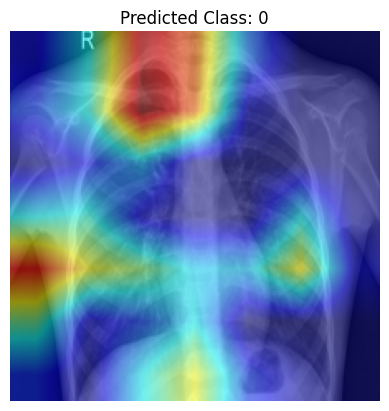

In [36]:
# Convert image to numpy
rgb_img = np.array(img.resize((224,224))) / 255.0

visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

plt.imshow(visualization)
plt.title(f"Predicted Class: {pred_class}")
plt.axis("off")
plt.show()